# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Haikal Javier Rachman
- Email: haikaljavierrachman@gmail.com
- Id Dicoding: Javierrachman

## Persiapan

### Menyiapkan library yang dibutuhkan

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib

### Menyiapkan data yang akan diguankan

In [19]:
# --- Load DATA ---
df = pd.read_csv('employee_data.csv')

## Data Understanding

In [20]:
# Info & preview dataset
df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


In [21]:
# Cek jumlah data duplikat
print("Jumlah data duplikat ada: ",df.duplicated().sum())

Jumlah data duplikat ada:  0


In [22]:
# Cek jumlah data null
print("Jumlah Data Null")
df.isna().sum()

Jumlah Data Null


,0
EmployeeId,0
Age,0
Attrition,412
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0


**Insight dari data:**

Tidak terdapat duplikat value pada dataset Terdapat 412 data null pada Attrition, dimana itu adalah parameter penting untuk analisis ini



In [23]:
# Cek persentase null
null_percent = df['Attrition'].isnull().sum() / len(df) * 100
print(f"Persentase Null pada Attrition: {null_percent:.2f}%")

Persentase Null pada Attrition: 28.03%


In [24]:
# Business Understanding: Cek Attrition Rate saat ini
attrition_rate = df['Attrition'].value_counts(normalize=True) * 100
print(f"Current Attrition Rate: {attrition_rate[1]:.2f}%")

Current Attrition Rate: 16.92%


## Data Preparation / Preprocessing

In [25]:
# --- DATA PREPARATION ---
# Drop data null
df = df.dropna()
df = df[df['Attrition'].isin([0, 1])]

In [26]:
# 2. Membersihkan Kolom yang tidak berguna
# EmployeeCount, StandardHours, Over18 biasanya hanya punya 1 nilai unik (konstan)
cols_to_drop = ['EmployeeId', 'EmployeeCount', 'StandardHours', 'Over18']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

In [27]:
# 3. Label Encoding untuk kolom kategorikal (Teks -> Angka)
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    if col != 'Attrition': # Jaga agar attrition tetap angka jika sudah 0/1
        df[col] = le.fit_transform(df[col].astype(str))

df.head(5)
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


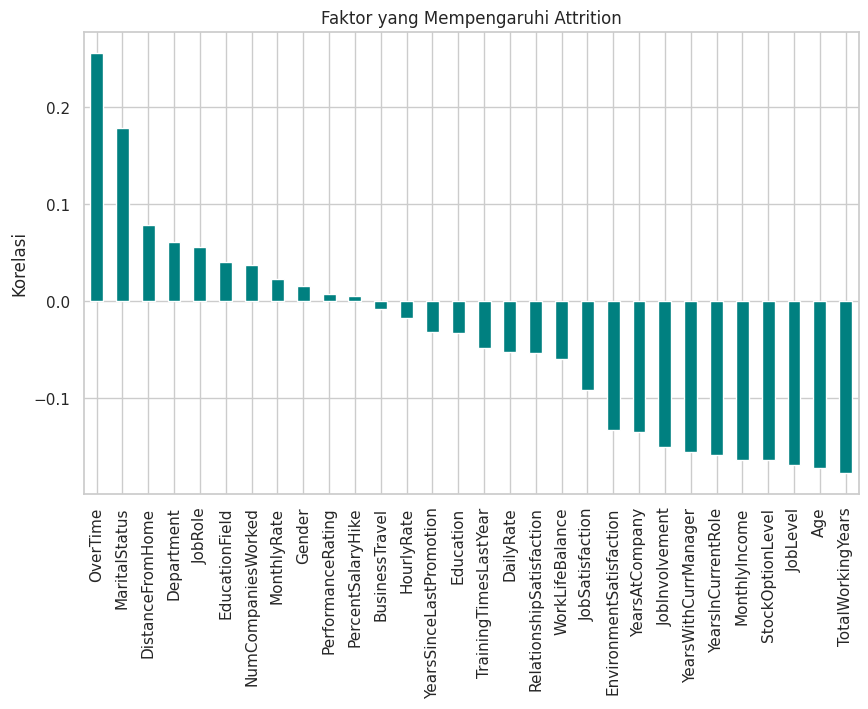

In [28]:
# --- EXPLORATORY DATA ANALYSIS (EDA) ---
# Mari lihat korelasi untuk membuktikan faktor penyebab
plt.figure(figsize=(10, 6))
correlation = df.corr()['Attrition'].sort_values(ascending=False)
correlation.drop('Attrition').plot(kind='bar', color='teal')
plt.title("Faktor yang Mempengaruhi Attrition")
plt.ylabel("Korelasi")
plt.show()

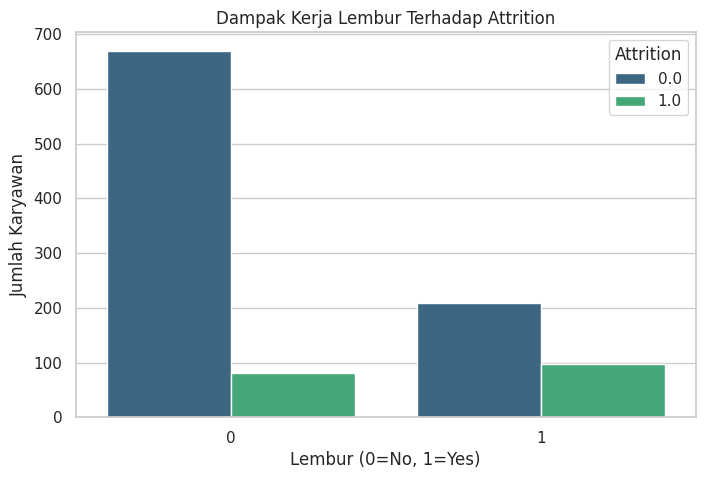

In [29]:
# Set style
sns.set_theme(style="whitegrid")

# 1. Visualisasi OverTime vs Attrition
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='OverTime', hue='Attrition', palette='viridis')
plt.title('Dampak Kerja Lembur Terhadap Attrition')
plt.xlabel('Lembur (0=No, 1=Yes)')
plt.ylabel('Jumlah Karyawan')
plt.show()

**Hasil yang didapat:** Terdapat perbedaan proporsi yang sangat kontras. Karyawan yang mendapatkan kebijakan lembur (OverTime: Yes) memiliki angka attrition yang jauh lebih tinggi dibandingkan mereka yang tidak lembur.

**Insight:** Lembur yang tidak terkendali menyebabkan ketidakseimbangan kehidupan kerja (work-life balance). Ini adalah "biang keladi" utama yang menyebabkan attrition rate perusahaan membengkak di atas 10%

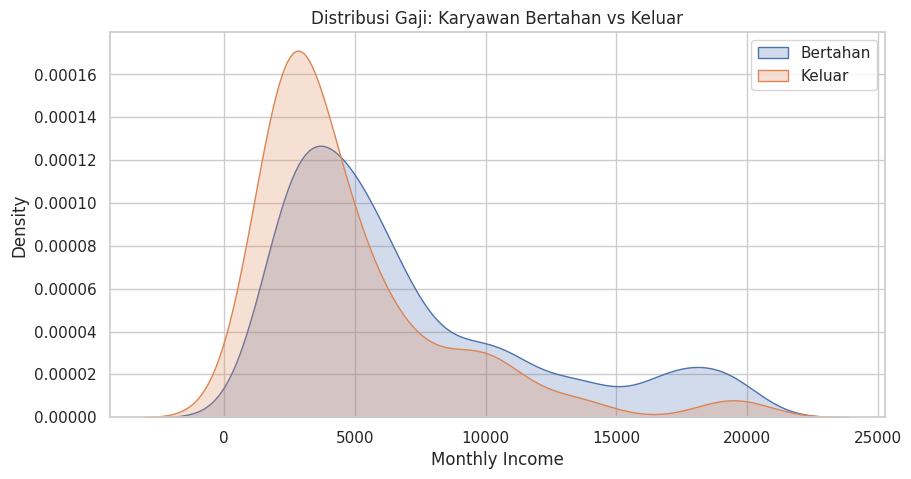

In [30]:
# 2. Distribusi Pendapatan Bulanan
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['Attrition'] == 0]['MonthlyIncome'], label='Bertahan', fill=True)
sns.kdeplot(df[df['Attrition'] == 1]['MonthlyIncome'], label='Keluar', fill=True)
plt.title('Distribusi Gaji: Karyawan Bertahan vs Keluar')
plt.xlabel('Monthly Income')
plt.legend()
plt.show()

**Hasil yang didapat**: Distribusi gaji karyawan yang keluar cenderung "miring ke kiri" (terkonsentrasi di angka yang rendah). Sebaliknya, karyawan yang bertahan memiliki distribusi gaji yang lebih luas hingga ke angka yang tinggi.

**Insight**: Karyawan dengan Monthly Income rendah adalah kelompok yang paling rentan untuk resign. Gaji yang tidak kompetitif, terutama untuk level jabatan rendah, membuat mereka mudah berpindah ke perusahaan lain.

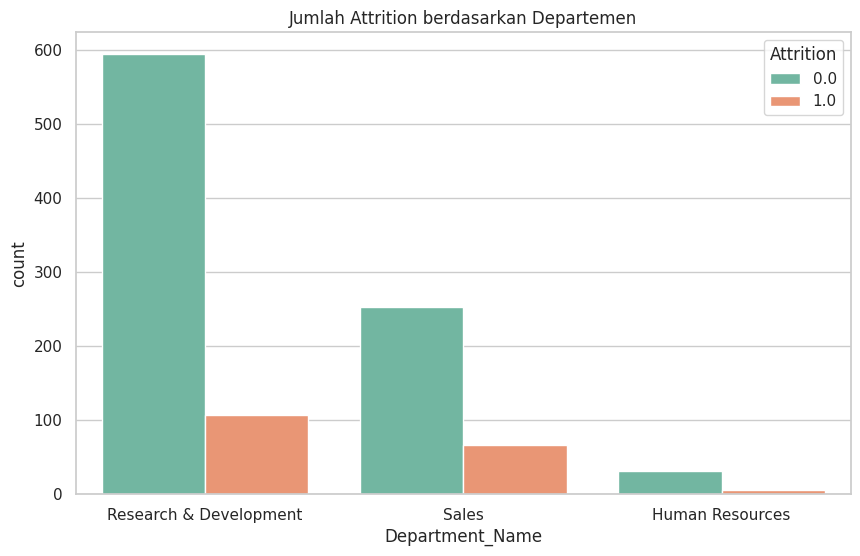

In [31]:
dept_map = {0: 'Human Resources', 1: 'Research & Development', 2: 'Sales'}
df_dept = df.copy()
df_dept['Department_Name'] = df_dept['Department'].map(dept_map)

# Visualisasi dengan Nama Asli
plt.figure(figsize=(10, 6))
sns.countplot(data=df_dept, x='Department_Name', hue='Attrition', palette='Set2')
plt.title('Jumlah Attrition berdasarkan Departemen')
plt.show()

/tmp/ipykernel_148/3211822781.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat, y='Attrition_Rate', data=temp, palette="viridis")


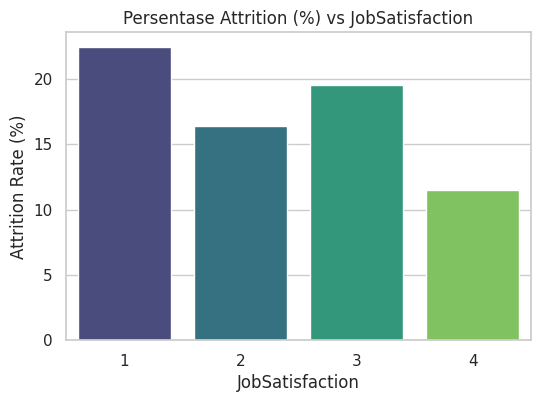

/tmp/ipykernel_148/3211822781.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat, y='Attrition_Rate', data=temp, palette="viridis")


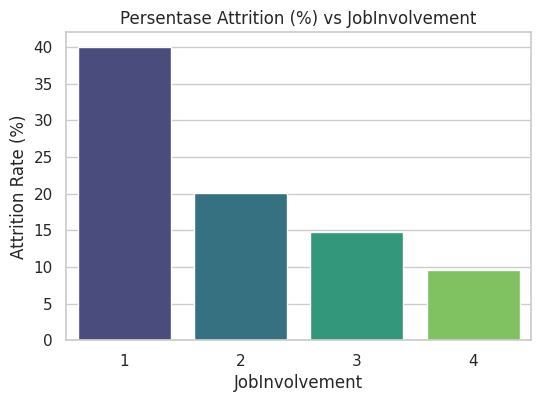

/tmp/ipykernel_148/3211822781.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat, y='Attrition_Rate', data=temp, palette="viridis")


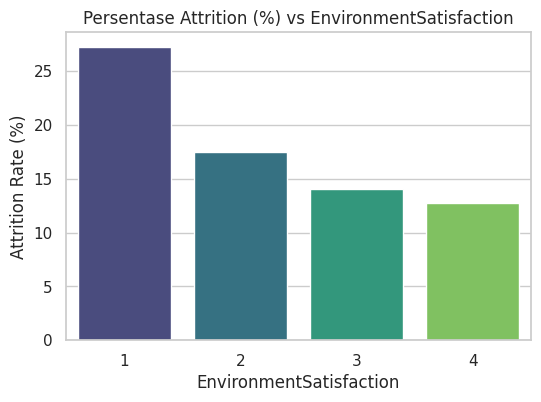

/tmp/ipykernel_148/3211822781.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat, y='Attrition_Rate', data=temp, palette="viridis")


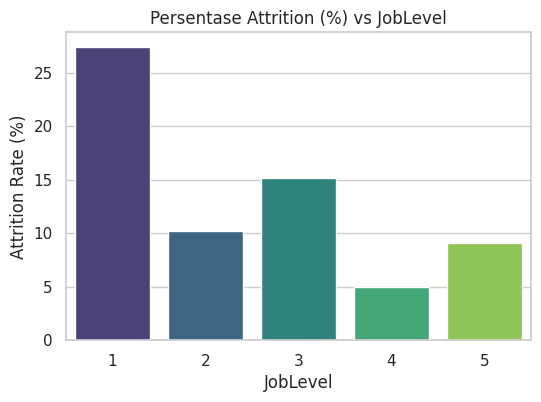

In [32]:
# Fitur yang ingin dianalisis
features = ['JobSatisfaction', 'JobInvolvement', 'EnvironmentSatisfaction', 'JobLevel']

for feat in features:
    plt.figure(figsize=(6,4))

    # Hitung rata-rata Attrition (ini akan menghasilkan angka 0 - 1 yang merepresentasikan %)
    # Gunakan df asli (bukan df_attrition) agar pembaginya adalah total karyawan
    temp = df.groupby(feat)['Attrition'].mean().reset_index()
    temp['Attrition_Rate'] = temp['Attrition'] * 100 # Ubah ke persen

    sns.barplot(x=feat, y='Attrition_Rate', data=temp, palette="viridis")
    plt.title(f'Persentase Attrition (%) vs {feat}')
    plt.ylabel('Attrition Rate (%)')
    plt.xlabel(feat)
    plt.show()

**Hasil yang didapat**: Karyawan yang keluar cenderung tersebar di berbagai tingkat kepuasan, namun ada konsentrasi yang cukup tinggi pada skor rendah (Level 1).

**Insight**: Meskipun jumlah orang yang keluar di level 3 atau 4 terlihat banyak (karena jumlah total karyawan di level tersebut memang banyak), secara rasio, karyawan dengan skor kepuasan 1 memiliki risiko keluar yang jauh lebih tinggi. Hal ini menunjukkan bahwa lingkungan kerja dan keterlibatan kerja yang buruk menjadi pemicu psikologis utama.

## Modeling

In [33]:
# 4. MEMBANGUN PIPELINE (Solusi untuk Error NaN & Recall Rendah)
# Pipeline ini akan otomatis:
# a. Mengisi NaN di fitur dengan nilai Median (SimpleImputer)
# b. Menyeimbangkan data (SMOTE)
# c. Menjalankan Model (RandomForest)

# 3. SPLIT DATA
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Mengisi NaN yang tersisa di fitur
    ('smote', SMOTE(random_state=42)),             # Menyeimbangkan kelas 0 dan 1
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 5. TRAINING
model_pipeline.fit(X_train, y_train)

# 6. EVALUASI
y_pred = model_pipeline.predict(X_test)
print("\n=== HASIL EVALUASI SETELAH PERBAIKAN (SMOTE + IMPUTER) ===")
print(classification_report(y_test, y_pred))


=== HASIL EVALUASI SETELAH PERBAIKAN (SMOTE + IMPUTER) ===
              precision    recall  f1-score   support

         0.0       0.88      0.96      0.92       176
         1.0       0.63      0.33      0.44        36

    accuracy                           0.85       212
   macro avg       0.75      0.65      0.68       212
weighted avg       0.83      0.85      0.83       212



## Evaluation

In [34]:
# Mendapatkan probabilitas (bukan langsung label 0/1)
y_probs = model_pipeline.predict_proba(X_test)[:, 1]

# Menurunkan threshold ke 0.3 (30%) agar lebih sensitif mendeteksi attrition
y_pred_tuned = (y_probs >= 0.3).astype(int)

print("\n=== HASIL EVALUASI DENGAN THRESHOLD 0.3 ===")
print(classification_report(y_test, y_pred_tuned))


=== HASIL EVALUASI DENGAN THRESHOLD 0.3 ===
              precision    recall  f1-score   support

         0.0       0.92      0.77      0.84       176
         1.0       0.38      0.67      0.48        36

    accuracy                           0.75       212
   macro avg       0.65      0.72      0.66       212
weighted avg       0.83      0.75      0.78       212

